# Lecture 2 — Temporal synchrony

In [13]:
# Housekeeping code...
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display

# The notebook normally runs from lectures/. This fallback also supports a kernel
# launched from the repository root.
if Path("../media").exists():
    MEDIA = Path("../media")
    DATA = Path("../data/fireflies")
elif Path("media").exists():
    MEDIA = Path("media")
    DATA = Path("data/fireflies")
else:
    raise FileNotFoundError("Run this notebook from the course repository.")

FPS = 60
DURATION_S = 5 * 60
COLORS = {"June 3": "#4C78A8", "June 11": "#E45756"}
NIGHT_LABELS = {
    "June 3": "June 3 (low density)",
    "June 11": "June 11 (peak density)",
}

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "bold",
})

def movie(filename, width=760):
    # Link local media without storing a second copy inside the notebook.
    return Video(
        str(MEDIA / filename),
        embed=False,
        width=width,
        html_attributes="controls loop muted playsinline",
    )

## In biological systems, *temporal synchronization* arrises at all scales

### 1. A crowd walking on a flexible bridge

[Millennium Bridge footage](https://www.youtube.com/watch?v=eAXVa__XWZ8); [Bocian *et al.* (2021)](https://doi.org/10.1038/s41467-021-27568-y).

In [14]:
movie("human-crowd-millennium-bridge-sway.mp4")

### 2. Courting male fiddler crabs

Source: [Reaney *et al.* (2008)](https://doi.org/10.1016/j.cub.2007.11.047), Movie S1.

In [15]:
movie("fiddler-crab-synchronous-waving.mp4")

### 3. Calcium and contraction in cardiac cells

Source: [Saraithong *et al.* (2025)](https://doi.org/10.1038/s42003-025-08162-0), Supplementary Movie 2.

In [16]:
movie("cardiomyocyte-monolayer-calcium-hd.mp4")

### 4. A firefly swarm

We will spend the next several lectures analyzing this data

Source: [Raphaël Sarfati et al., Self-organization in natural swarms of Photinus carolinus synchronous fireflies. Sci. Adv. (2021)](https://www.science.org/doi/10.1126/sciadv.abg9259)

Dataset: [Sarfati, Hayes, and Peleg (2023), Dryad](https://doi.org/10.5061/dryad.2547d7wvn).

In [17]:
movie("firefly-synchrony.mp4")

## Where does synchrony come from?

Possible mechanisms:

- An **external cue** drives everyone at once.
- A **leader** sets the timing.
- **Mutual coupling** lets units adjust to one another and synchrony *emerges*.
- The **initial conditions** produce matched timing without interaction.

> ### Demo
> 
> Here are the rules:
> 
> -  Keep you hands down.
> -  If you have the urge, quickly raise you hand and then lower it.
> -  If you see someone else raise their hand you have to do the same and then lower it.

### How could we test these ideas?

| Candidate origin | A decisive question or intervention |
| --- | --- |
| External cue | Does coordination persist when units receive different cues, or when the cue is removed/saturated? |
| Leader | What happens when the suspected leader is removed or altered? |
| Mutual coupling | Disrupt the coupling: vision, sound, touch, electrical contact  |
| Initial conditions | After setting matched or deliberately offset initial conditions, do isolated units retain the predicted timing relationship? Do they dephase over time? |

### How do systems use temporal synchronization?

| System | Proposed explanation |
| --- | --- |
| Fiddler crabs | Mate attraction: earliest waver gets the girl |
| Cardiomyocytes | Coordinated tissue activation and heart pumping |
| Fireflies | Mate attraction |
| Bridge crowd | A striking emergent collective motion, actually not so good ... |

> ### Discussion Question
>
> How do we *measure* synchrony?

## Common scalar measures of synchrony

- **Phase order:** phases align.
- **Pairwise phase locking:** phase differences stay fixed.
- **Event coincidence:** events occur within the same time window.
- **Correlation peak:** signals rise and fall together.
- **Spectral coherence:** oscillations share frequency and phase.
- **Count fluctuations:** population activity arrives in bursts.

**Which can we use if we cannot identify individuals?**

## The biological clockwork of *Photinus carolinus*

<img src="../media/firefly-photinus-carolinus-closeup.jpg" width="600" style="display: block; margin: 0 auto;">

Flying males produce temporal light flash patterns and females can reply from near the ground.

Relevant timescales:

| Pattern | What happens | Timescale |
| --- | --- | ---: |
| Flash | One male emits one pulse | 0.10–0.15 s |
| Flash train | One male emits 1–8 flashes | 0.55 s between flashes |
| Collective burst | Many males flash together | ~10 s |
| Burst recurrence | One collective burst to the next | ~12 s |
| Nightly display | Swarm activity after sunset | ~3 h |
| Mating season | Peak activity each year | ~2 weeks |

Synchrony provides a species-specific signal to the female (other species can also be flashing). The dark interval gives the female a chance to respond. Of course, the males are all competing with each other ...

## Data acquisition

Summer recordings in Great Smoky Mountains National Park. The authors use *stereo imaging* to achieve 3D localization of flashes. 

- **Acquire:** two *synchronized* Sony $\alpha$ 7R IV cameras about 4 m apart; 60 fps, 1/60 s exposure, f/1.8, ISO 32,000, focus at infinity.
- **Calibrate space and time:** a 25 mm checkerboard at 5–10 positions; then a brief artificial light signal checked by cross-correlation.
- **Detect and reconstruct:** threshold bright pixels, match observations between views, triangulate 3D position, and filter impossible geometry.

About 60% of visible detections could be triangulated, and roughly 1% of obvious geometric outliers were removed.

### Stereo vision

<img src="../media/firefly-stereo-camera-geometry.png" width="800" style="display: block; margin: 0 auto;">

3D inference: Find the 3D point where the two rays intersect, within noise limits:

$$
\mathbf{X} \approx \mathbf{C}_1 + s_1\hat{\mathbf{r}}_1
             \approx \mathbf{C}_2 + s_2\hat{\mathbf{r}}_2.
$$

The shift of the flash between the two images is **parallax**. A wider camera separation generally makes depth easier to estimate, but shrinks the common field of view and can make matching harder.

![](../media/firefly-paper-figure-1-methods.png)

## The released data: one observation per row

Paper data was released on [Dryad](https://doi.org/10.5061/dryad.2547d7wvn) and is a series of headerless tables. 

Each row records 3D position and time (frame rate=60Hz) for one reconstructed detection. Here are the first 8 rows:

In [18]:
example_observations = pd.read_csv(
    DATA / "xyzt0611-class-window.csv",
    header=None,
    names=["x_m", "y_m", "z_m", "frame"],
)
example_observations.head(8)

,x_m,y_m,z_m,frame
0,-7.531038,22.892096,3.581177,129123
1,-7.525087,22.885565,3.583405,129124
2,0.261178,4.926277,0.538077,129124
3,-7.530197,22.902191,3.586181,129125
4,-1.176840,8.471946,1.422866,129125
5,0.260660,4.927213,0.537699,129125
6,-7.526875,22.898629,3.587569,129126
7,-1.177009,8.472198,1.422700,129126


In [19]:
movie("firefly-synchrony.mp4")

## Bursts of flashing

Flashes come in synchronized trains and bursts. We can see this by counting the number of detections in each camera frame.

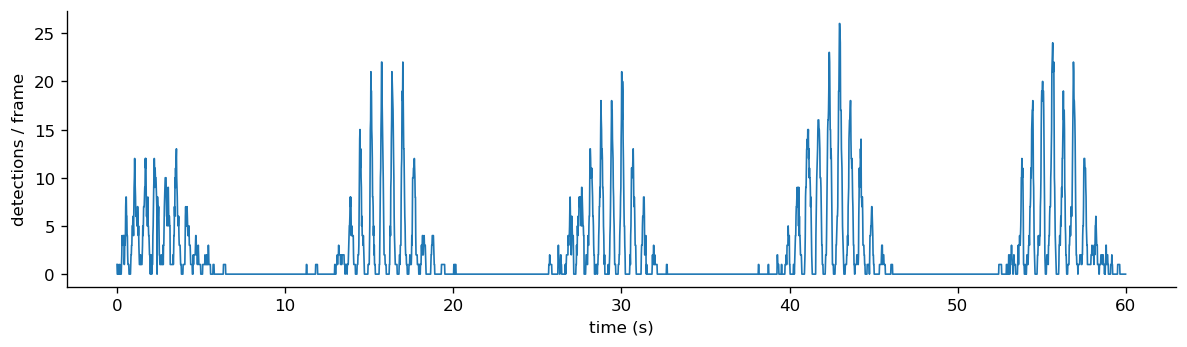

In [20]:
frames = np.arange(
    example_observations["frame"].min(),
    example_observations["frame"].max() + 1,
)
detections_per_frame = (
    example_observations.groupby("frame")
    .size()
    .reindex(frames, fill_value=0)
    .to_numpy()
)
time_s = (frames - frames[0]) / FPS

start_s = 231
show = (time_s >= start_s) & (time_s < start_s + 60)

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(time_s[show] - start_s, detections_per_frame[show], lw=1)
ax.set(xlabel="time (s)", ylabel="detections / frame")
fig.tight_layout()
plt.show()

## Activity over the season

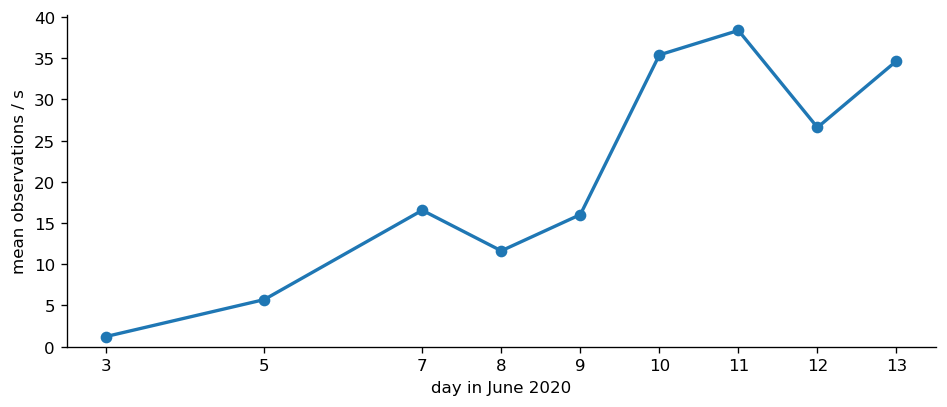

In [21]:
daily_activity = pd.read_csv(DATA / "daily-observation-counts.csv")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(
    daily_activity["day"],
    daily_activity["observations_per_second"],
    "o-",
    lw=2,
    ms=6,
)
ax.set(
    xlabel="day in June 2020",
    ylabel="mean observations / s",
    xticks=daily_activity["day"],
)
ax.set_ylim(bottom=0)
fig.tight_layout()
plt.show()

## Low and high activity

Compare the busiest five-minute window on:

- **June 3:** low activity
- **June 11:** peak activity

In [22]:
WINDOWS = {
    "June 3": ("xyzt0603-class-window.csv", 317_172),
    "June 11": ("xyzt0611-class-window.csv", 129_112),
}

def read_firefly_window(filename, start_frame):
    observations = pd.read_csv(
        DATA / filename,
        header=None,
        names=["x_m", "y_m", "z_m", "frame"],
    )
    observations["time_s"] = (observations["frame"] - start_frame) / FPS
    return observations

fireflies = {
    night: read_firefly_window(filename, start_frame)
    for night, (filename, start_frame) in WINDOWS.items()
}

pd.DataFrame({
    "observations": {night: len(df) for night, df in fireflies.items()},
    "duration (s)": DURATION_S,
}).rename(index=NIGHT_LABELS)

,observations,duration (s)
June 3 (low density),782,300
June 11 (peak density),28721,300


## High and low density days

Let's look at a low density (few observations day, June 3) and a high density day (June 11)"

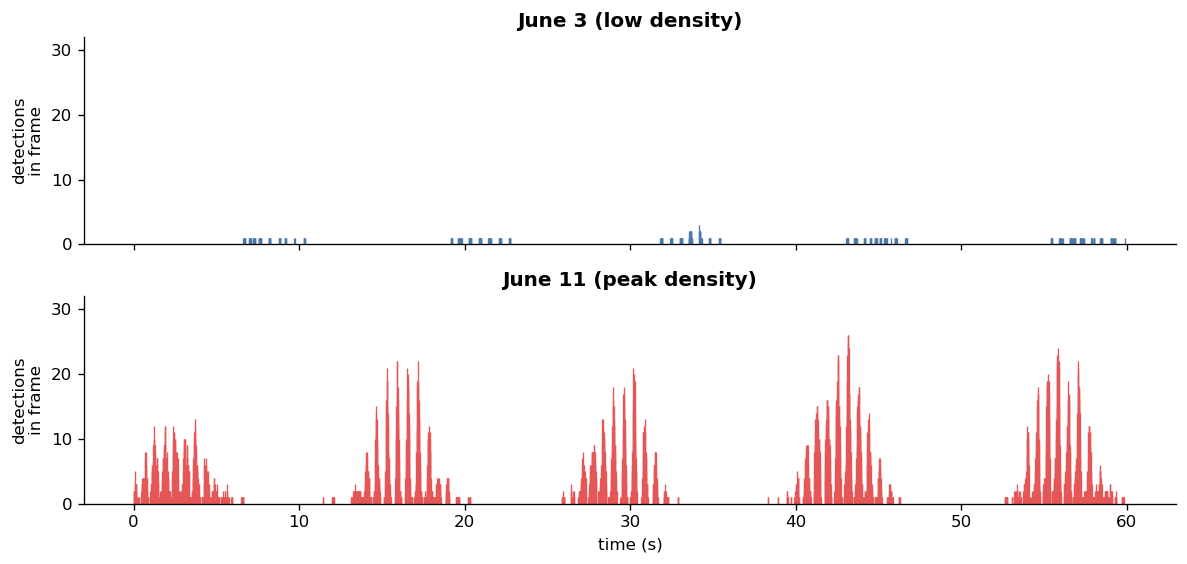

In [23]:
ACTIVITY_START_S = {"June 3": 14, "June 11": 231}
ACTIVITY_DURATION_S = 60

fig, axes = plt.subplots(2, 1, figsize=(10, 4.8), sharex=True, sharey=True)

for ax, (night, observations) in zip(axes, fireflies.items()):
    first_frame = WINDOWS[night][1] + round(ACTIVITY_START_S[night] * FPS)
    frames = np.arange(first_frame, first_frame + ACTIVITY_DURATION_S * FPS)
    counts = observations.groupby("frame").size().reindex(frames, fill_value=0)
    time_s = (frames - first_frame) / FPS

    ax.vlines(time_s, 0, counts, lw=0.8, color=COLORS[night])
    ax.set_title(NIGHT_LABELS[night])
    ax.set_ylabel("detections\nin frame")
    ax.set_ylim(0, 32)

axes[-1].set_xlabel("time (s)")
fig.tight_layout()
plt.show()

Low density: mostly single detections, separated in time.

Peak density: many detections occur in the same frames and recur in bursts.

> ### Discussion Question
>
> How do we *measure* synchrony for the fireflies?

## Problem: We do not know who is who

It would be natural to track flies and count coincident flashes. But we can't track flies over time.

No identities $\longrightarrow$ no individual timing or pairwise coincidence calculation.

All we have is $N(t)$: detections per frame.

Can we **measure synchrony through the fluctuations of $N(t)$?**

## Write the population count as a sum

Imagine $M$ active fireflies with hidden flash states

$$
X_i(t)=\begin{cases}1 & \text{firefly }i\text{ is flashing}\\0 & \text{otherwise,}\end{cases}
\qquad
N(t)=\sum_{i=1}^{M}X_i(t).
$$

For each five-minute window define:

$$
\mu=\langle N\rangle,
\qquad
\sigma_N^2=\operatorname{Var}(N).
$$

## Independent flashes: variances add

$$
\operatorname{Var}(N)
=\sum_i\operatorname{Var}(X_i)
+2\sum_{i<j}\operatorname{Cov}(X_i,X_j).
$$

Independent flashes have zero covariance. If each firefly flashes with probability $p$ per frame,

$$
\mu=Mp,
\qquad
\sigma_N^2=Mp(1-p)\approx Mp=\mu
\qquad (p\ll1).
$$

Therefore

$$
\boxed{\sigma_N\sim\sqrt{\mu}}.
$$

Double the number of active fireflies: $\mu$ doubles, but $\sigma_N$ grows only by $\sqrt{2}$.

## Collective bursts: amplitudes add

In the perfectly synchronized limit, every firefly shares one flash state $Y(t)$:

$$
X_i(t)=Y(t),
\qquad
N(t)=M Y(t),
\qquad
P(Y=1)=p.
$$

Then

$$
\mu=Mp,
\qquad
\sigma_N=M\sqrt{p(1-p)}
=\mu\sqrt{\frac{1-p}{p}}.
$$

For comparable burst duty cycle $p$,

$$
\boxed{\sigma_N\sim\mu}.
$$

Double the number participating in a burst: both $\mu$ and $\sigma_N$ double.

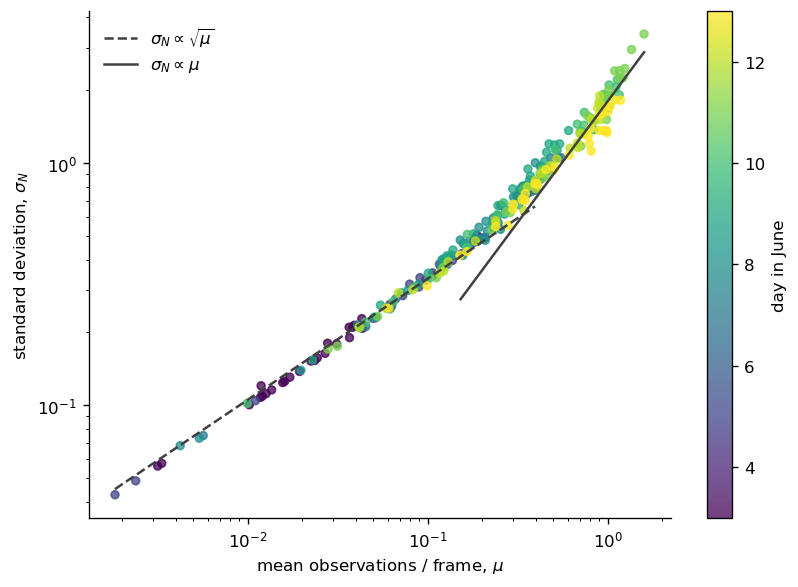

In [24]:
window_stats = pd.read_csv(DATA / "five-minute-window-statistics.csv")
mu = window_stats["mean_observations_per_frame"]
sigma = window_stats["sd_observations_per_frame"]

low = mu < 0.2
high = mu > 0.8
sqrt_scale = np.median(sigma[low] / np.sqrt(mu[low]))
linear_scale = np.median(sigma[high] / mu[high])
guide_mu = np.logspace(np.log10(mu.min()), np.log10(mu.max()), 200)

fig, ax = plt.subplots(figsize=(7, 5))
points = ax.scatter(
    mu,
    sigma,
    c=window_stats["day"],
    cmap="viridis",
    s=22,
    alpha=0.75,
)
ax.plot(
    guide_mu[guide_mu <= 0.4],
    sqrt_scale * np.sqrt(guide_mu[guide_mu <= 0.4]),
    "--",
    color="0.25",
    label=r"$\sigma_N \propto \sqrt{\mu}$",
)
ax.plot(
    guide_mu[guide_mu >= 0.15],
    linear_scale * guide_mu[guide_mu >= 0.15],
    "-",
    color="0.25",
    label=r"$\sigma_N \propto \mu$",
)
ax.set(
    xscale="log",
    yscale="log",
    xlabel=r"mean observations / frame, $\mu$",
    ylabel=r"standard deviation, $\sigma_N$",
)
ax.legend(frameon=False)
fig.colorbar(points, ax=ax, label="day in June")
fig.tight_layout()
plt.show()

Paper figure: 

![Firefly activity and temporal clustering](../media/firefly-paper-figure-1-results.png)

The complete camera detections show two regimes:

$$
\text{low density: } \sigma_N\sim\sqrt{\langle N\rangle}
\qquad\longrightarrow\qquad
\text{high density: } \sigma_N\sim\langle N\rangle.
$$

Fitted exponents: 0.53 at low density and 0.86 at high density, with a crossover near $\langle N\rangle=0.3$.

**Conclusion 1:** Above a density threshold, the swarm switches from uncorrelated flashes to synchronous bursts.

Two isolated fireflies might try to synchronize.

The authors propose that high density changes **network connectivity**, not the basic response to a neighbor.

## Mechanism needs space

An instantaneous global cue predicts simultaneous onset. Local coupling predicts propagation.

![](../media/firefly-paper-figure-2-propagation.png)

Color shows time before or after the burst peak, in seconds.

- early flashes are localized;
- later flashes occur progressively farther away;
- the front travels at about $0.5$ m/s.

The fireflies do not flow with the front. **Information moves; animals do not.**

## Proposed mechanism

**Visible flash $\rightarrow$ neighbor responds $\rightarrow$ relay across the swarm**

Terrain, vegetation, and orientation continually change who can see whom. High density provides enough visual links to carry the collective timing.

## Sources

- Raphaël Sarfati, Julie C. Hayes, Elie Sarfati, and Orit Peleg, [“Spatio-temporal reconstruction of emergent flash synchronization in firefly swarms via stereoscopic 360-degree cameras”](https://doi.org/10.1098/rsif.2020.0179), *Journal of the Royal Society Interface* 17 (2020).
- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [“Self-organization in natural swarms of *Photinus carolinus* synchronous fireflies”](https://doi.org/10.1126/sciadv.abg9259), *Science Advances* 7 (2021).
- Raphael Sarfati, Julie C. Hayes, and Orit Peleg, [3D time-resolved flash-occurrence dataset](https://doi.org/10.5061/dryad.2547d7wvn), Dryad (2023).